# 实验八：彩色图像处理与伪彩色增强

**实验目的：**
了解彩色图像在不同应用场景下的处理方法，掌握伪彩色映射和基于 HSV 空间的颜色分割技术。


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5), is_color=True):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i]
        if is_color and len(img.shape) == 3:
            # OpenCV 默认是 BGR，Matplotlib 需要 RGB 才能正确显示颜色
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
        else:
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1. 伪彩色处理 (Pseudo-color Enhancement)
人眼只能分辨几十种灰度级，但能分辨成千上万种颜色。
在医学图像（如 X 光、B 超、热成像）或卫星遥感中，我们经常使用**色彩映射表 (Colormap)** 将灰度映射为彩色，以突出肉眼难以察觉的微小细节。


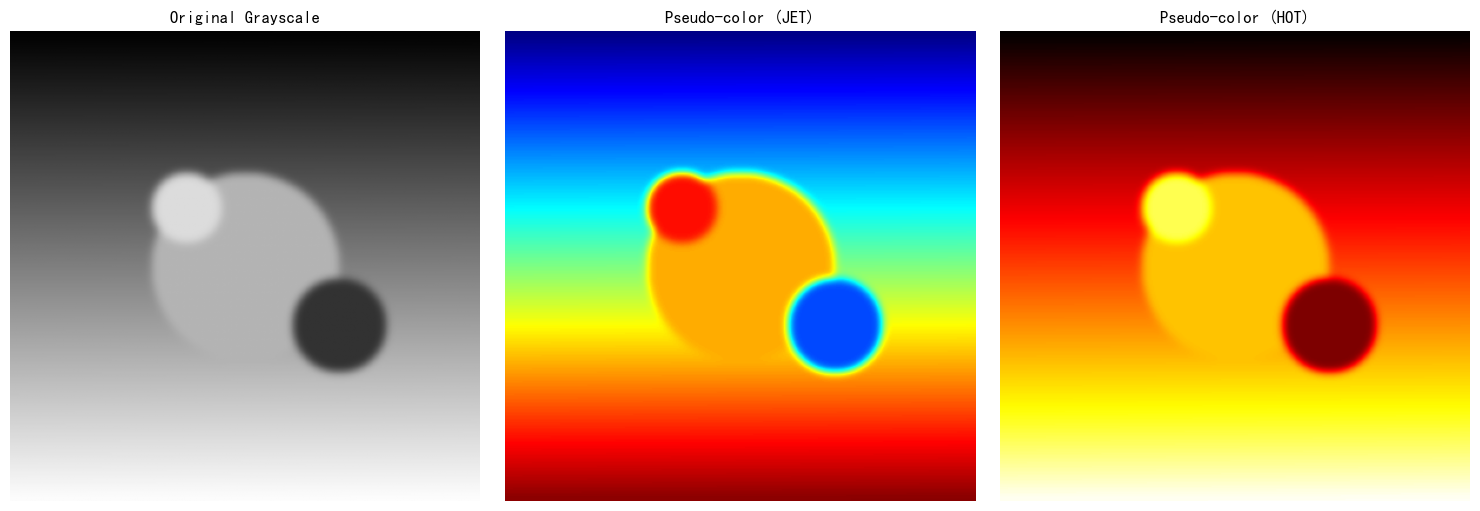

💡 结论：伪彩色让原本灰蒙蒙的图像瞬间有了强烈的层次感，不同密度的区域一目了然！


In [2]:
# 自动生成一张类似医学扫描的灰度渐变图 (带有不同灰度的斑块)
gray_medical = np.linspace(0, 255, 400 * 400).reshape(400, 400).astype(np.uint8)
cv2.circle(gray_medical, (200, 200), 80, 180, -1)
cv2.circle(gray_medical, (150, 150), 30, 220, -1)
cv2.circle(gray_medical, (280, 250), 40, 50, -1)

# 添加一点高斯模糊让边缘更真实
gray_medical = cv2.GaussianBlur(gray_medical, (21, 21), 0)

# 应用伪彩色映射表
# COLORMAP_JET 是最常用的伪彩色表：低值为蓝，中值为绿黄，高值为红
pseudo_jet = cv2.applyColorMap(gray_medical, cv2.COLORMAP_JET)

# COLORMAP_HOT 模拟热力图：黑-红-黄-白
pseudo_hot = cv2.applyColorMap(gray_medical, cv2.COLORMAP_HOT)

show_images([gray_medical, pseudo_jet, pseudo_hot], 
            ["Original Grayscale", "Pseudo-color (JET)", "Pseudo-color (HOT)"], 
            is_color=True)

print("💡 结论：伪彩色让原本灰蒙蒙的图像瞬间有了强烈的层次感，不同密度的区域一目了然！")


## 2. 彩色图像平滑：RGB 空间 vs HSV 空间
[Image of HSV color space cylinder]
如果我们想对一张彩色图片进行平滑去噪，有两种做法：
1. 在 RGB 空间中，对 R、G、B 三个通道分别进行平滑。这容易导致**颜色边缘发生混合（边缘出现杂色）**。
2. 将图像转入 HSV（色调、饱和度、明度）空间，**仅对 V（明度）通道进行平滑**，然后转回 RGB。这样能完美保留原本的颜色特征！


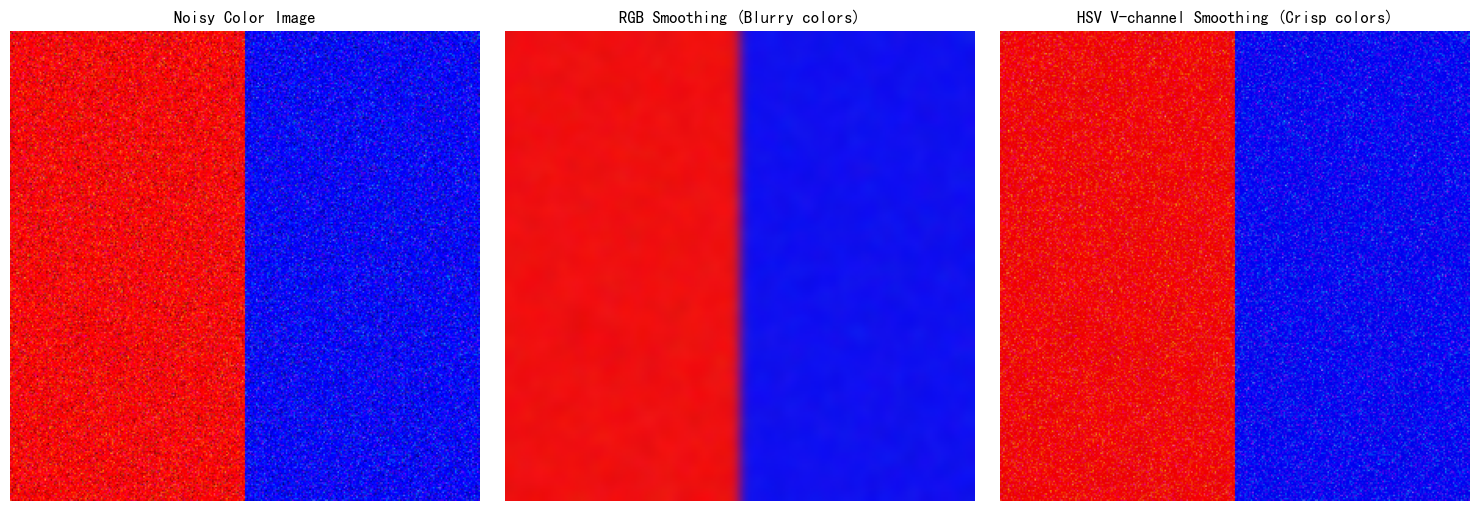

In [3]:
# 自动生成一张彩色带噪点的图像
color_img = np.zeros((300, 300, 3), dtype=np.uint8)
color_img[:, :150] = [0, 0, 255]   # 左半边红色 (BGR)
color_img[:, 150:] = [255, 0, 0]   # 右半边蓝色 (BGR)

# 强行添加高斯噪声
noise = np.random.normal(0, 40, color_img.shape)
color_noisy = np.clip(color_img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# 策略 1：RGB 空间整体平滑
rgb_smoothed = cv2.GaussianBlur(color_noisy, (21, 21), 0)

# 策略 2：HSV 空间仅平滑 V 通道
hsv_img = cv2.cvtColor(color_noisy, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv_img)
# 仅对 V 通道（明度）进行平滑去噪
V_smoothed = cv2.GaussianBlur(V, (21, 21), 0)
# 重新合并通道并转回 BGR
hsv_merged = cv2.merge([H, S, V_smoothed])
hsv_smoothed = cv2.cvtColor(hsv_merged, cv2.COLOR_HSV2BGR)

show_images([color_noisy, rgb_smoothed, hsv_smoothed], 
            ["Noisy Color Image", "RGB Smoothing (Blurry colors)", "HSV V-channel Smoothing (Crisp colors)"])


## 3. 彩色图像分割 (基于 HSV 空间)
你想开发一个自动分拣苹果的机器人吗？如果用 RGB 去找红色，由于光照变化，RGB 的值会剧烈波动。
但在 HSV 空间，**H（色调）主要由物体的本色决定，受光照影响极小**。我们只需框定红色的 H 范围即可！


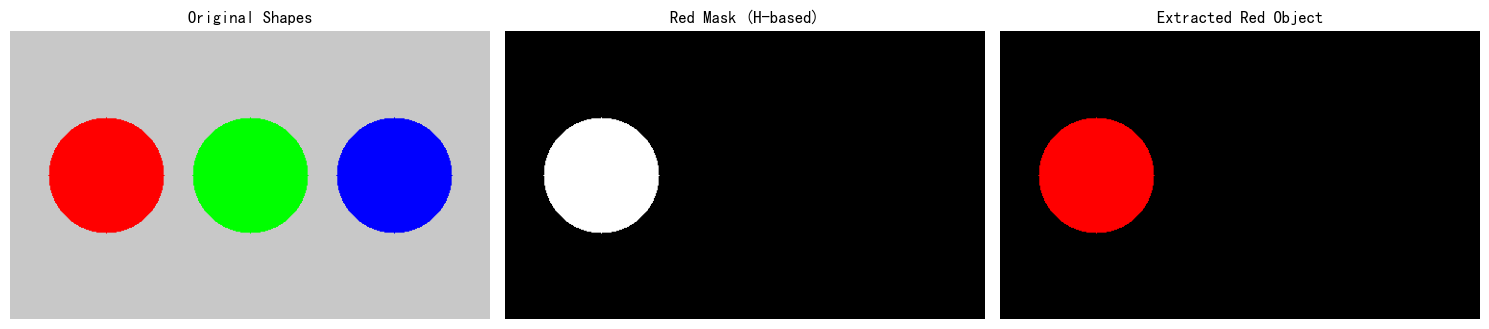

💡 结论：通过设定 HSV 的区间，我们可以像变魔术一样精确地将特定颜色的物体从背景中剥离出来！


In [ ]:
# 自动生成一张包含不同颜色物体的测试图
shapes_img = np.full((300, 500, 3), 200, dtype=np.uint8) # 浅灰背景
cv2.circle(shapes_img, (100, 150), 60, (0, 0, 255), -1)   # 红球 (BGR)
cv2.circle(shapes_img, (250, 150), 60, (0, 255, 0), -1)   # 绿球 (BGR)
cv2.circle(shapes_img, (400, 150), 60, (255, 0, 0), -1)   # 蓝球 (BGR)

# 转换到 HSV 空间
hsv_shapes = cv2.cvtColor(shapes_img, cv2.COLOR_BGR2HSV)

# OpenCV 中 H 的范围是 0-180。红色刚好分布在 H=0 附近，所以包含两段：0-10 和 170-180
# 我们设定阈值范围来提取红色
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
mask1 = cv2.inRange(hsv_shapes, lower_red1, upper_red1)

lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])
mask2 = cv2.inRange(hsv_shapes, lower_red2, upper_red2)

# 合并两个红色掩码
red_mask = mask1 + mask2

# 使用按位与操作 (bitwise_and) 把红球抠出来
extracted_red = cv2.bitwise_and(shapes_img, shapes_img, mask=red_mask)

show_images([shapes_img, red_mask, extracted_red], 
            ["Original Shapes", "Red Mask (H-based)", "Extracted Red Object"])

print(" 结论：通过设定 HSV 的区间，我们可以像变魔术一样精确地将特定颜色的物体从背景中剥离出来！")
